# Predict regulators of Th1 polarization - example

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
import numpy as np
from pert2state_model import Perturb2StateModel

## Load target signature

In [3]:
signature_df = pd.read_csv("../data/Th1_vs_Th0_DE_results.csv")
signature_df["zscore"] = signature_df["log_fc"] / signature_df["lfcSE"]
y_target = signature_df.set_index("variable")["zscore"]
y_target.head()

variable
IL5     -10.690899
CHDH    -10.686937
IFNG      8.939524
NEK6     -8.913758
RCAN2     8.569012
Name: zscore, dtype: float64

## Load perturb-seq signatures

In [5]:
X_perturbs = pd.read_parquet("../data/X_perturbs_example.parquet")
print(X_perturbs.shape)
X_perturbs.head()

(10079, 8481)


target_contrast_gene_name,PHF23,GTSE1,SLC25A24,C11orf21,AMPD2,SLC19A2,SNX19,RNF11,MKKS,RAB11FIP4,...,MAML3,MYO5A,ZNF677,DENND1B,LYRM4,FAM185A,SMKR1,ZCCHC3,GTF2I,ZNF8
TSPAN6,0.000031,-0.001675,-0.000571,0.001283,-0.002225,-0.003502,-0.004917,-0.003417,-0.003227,-0.000422,...,0.004040,-0.003290,-0.001137,-0.002414,0.004255,0.000291,0.003376,-0.005945,0.002168,0.004748
DPM1,-2.345064,-0.890755,0.388036,0.518532,0.009509,0.576856,1.140915,0.558893,1.800250,0.066911,...,-0.253093,-0.646893,1.406199,-0.560932,-0.469456,-2.312685,-0.529010,0.633796,-1.009814,0.266056
C1orf112,-2.731677,-1.175347,-0.510581,0.189036,0.785539,0.939145,0.348139,0.385045,0.341441,-1.414727,...,-1.809285,1.226235,-0.374978,0.043698,-1.097482,0.655274,-1.123329,0.314860,-1.961700,-1.894995
FGR,-0.026447,-0.054137,-0.022519,-0.013020,-0.052535,0.106619,0.106937,0.107879,-0.046939,-0.037826,...,-0.007845,-0.058256,-0.043047,-0.065604,0.014856,-0.044049,0.146495,0.094175,-0.017213,0.193529
CFH,2.609565,-1.288298,-0.303061,-0.928687,0.038726,0.823456,-1.088516,-0.476845,-0.558944,-0.233488,...,-0.576311,0.591252,0.057515,2.571778,-0.447438,-0.854589,-0.502774,0.114249,1.041685,0.571221


In [6]:
common_gs = np.intersect1d(y_target.index, X_perturbs.index)
sample_common_gs = np.random.choice(common_gs, 3000, replace=False)

X_perturbs = X_perturbs.loc[sample_common_gs]
y_target = y_target.loc[sample_common_gs]

## Fit model of target state from perturbations

In [7]:
model = Perturb2StateModel(pca_transform=True, n_splits=3, n_repeats=1, l1_ratio=np.logspace(-1, 1, 10), alpha=[1])
model.fit(X_perturbs.loc[sample_common_gs], y_target.loc[sample_common_gs], model_id="test")
model.summarize_eval()

,alpha,alpha_se,l1_ratio,l1_ratio_se,train_r2,train_r2_se,train_spearman,train_spearman_se,train_pearson,train_pearson_se,...,test_pearson,test_pearson_se,test_kendall,test_kendall_se,test_spearman_p,test_spearman_p_se,test_pearson_p,test_pearson_p_se,test_kendall_p,test_kendall_p_se
model_id,,,,,,,,,,,,,,,,,,,,,
test,1.0,0.0,0.1,0.0,0.3167,0.0067,0.5567,0.0088,0.5667,0.0067,...,0.54,0.01,0.3733,0.012,0.0,0.0,0.0,0.0,0.0,0.0


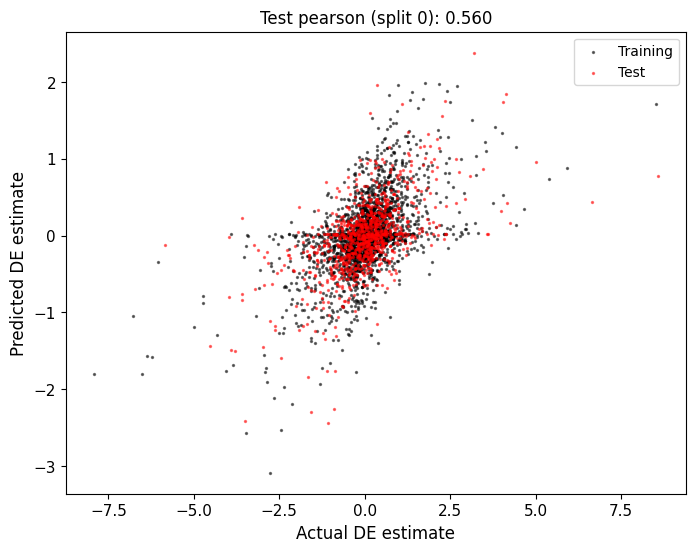

In [12]:
pl = model.plot_prediction(X_perturbs, y_target, plot_metric="pearson", split_id=0)

In [16]:
predicted = model.get_prediction(X_perturbs, y_target)
predicted.head()

,pred_mean,pred_sem
LZTS2,-0.048568,0.003614
STX7,0.056890,0.005956
HSPA4L,-0.005596,0.002600
ARHGEF12,-0.117162,0.010711
KIAA0040,0.091892,0.022437


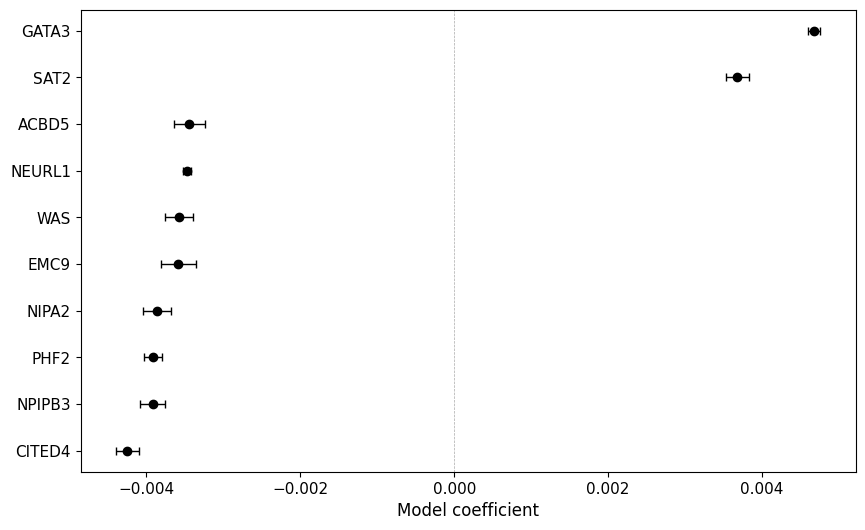

In [17]:
pl = model.plot_coefs(top_n=10)

In [18]:
coefs = model.get_coefs()
coefs.head()

,coef_mean,coef_sem
PHF23,0.000042,0.000077
GTSE1,-0.002353,0.000169
SLC25A24,0.000311,0.000050
C11orf21,-0.000672,0.000135
AMPD2,0.000900,0.000199
